Устанавливаем соединение с PostgreSQL...
Соединение успешно установлено!


C:\Users\User\AppData\Local\Temp\ipykernel_19648\3408360639.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_products = pd.read_sql("SELECT * FROM mart.product_sales;", conn)
C:\Users\User\AppData\Local\Temp\ipykernel_19648\3408360639.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_customers = pd.read_sql("SELECT * FROM mart.customer_value;", conn)
C:\Users\User\AppData\Local\Temp\ipykernel_19648\3408360639.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_orders_raw = pd.read_sql("SELECT order_id, orde

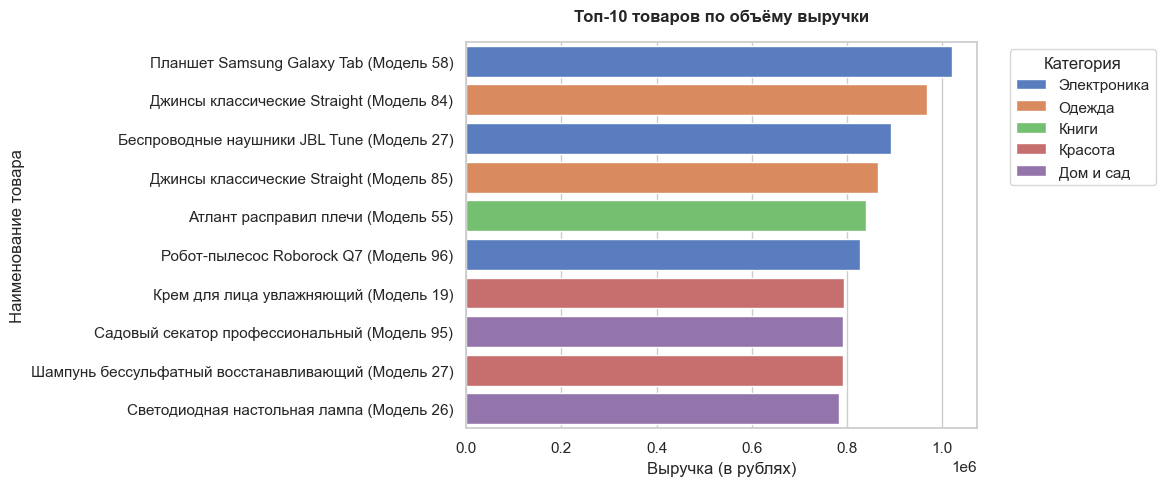

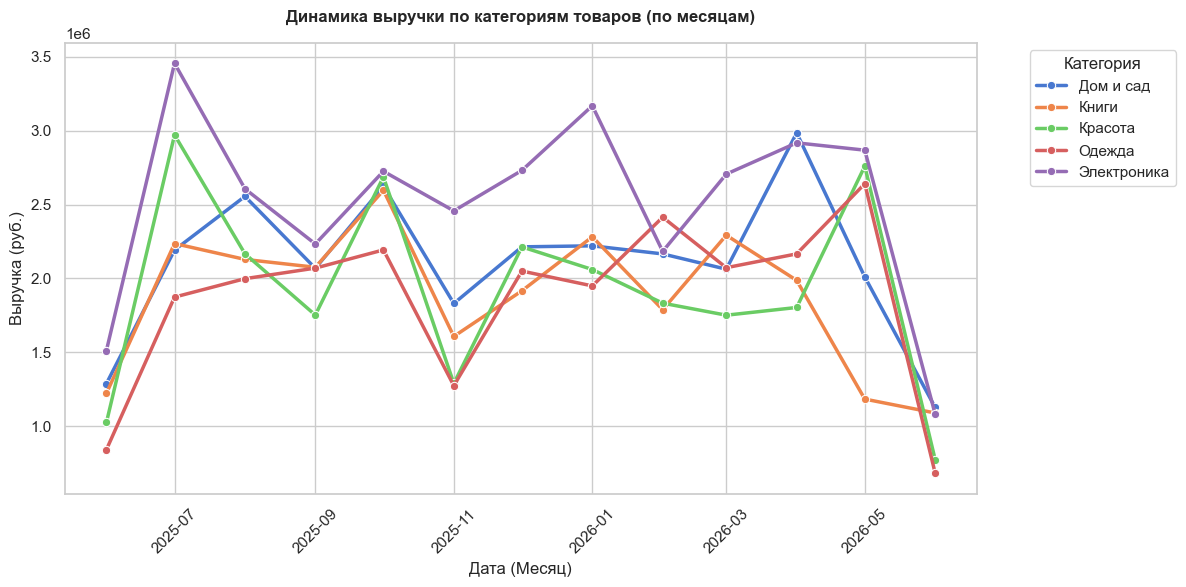

C:\Users\User\AppData\Local\Temp\ipykernel_19648\3408360639.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


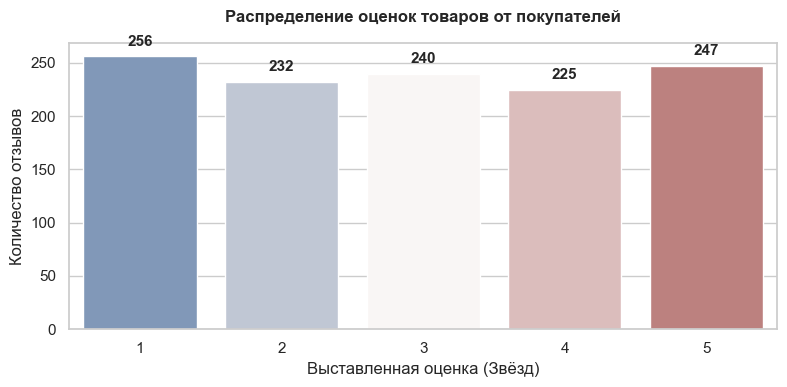

C:\Users\User\AppData\Local\Temp\ipykernel_19648\3408360639.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


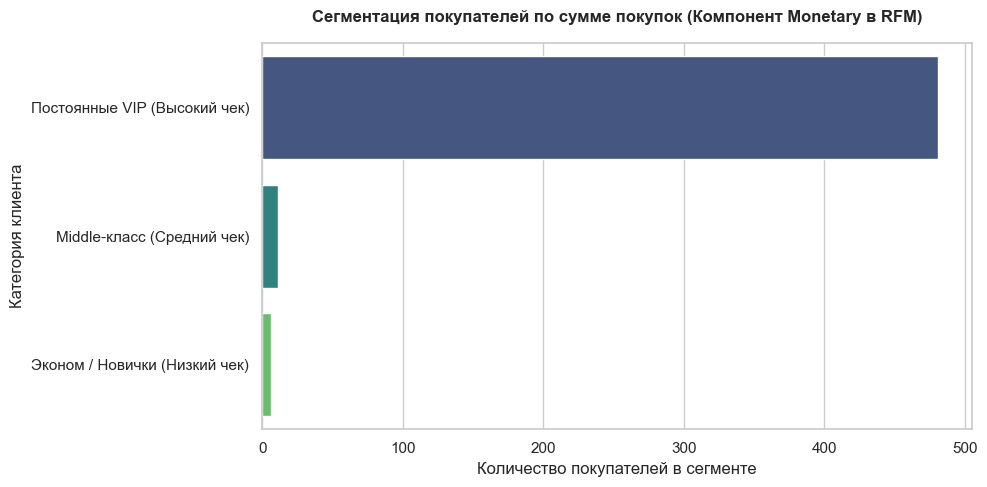

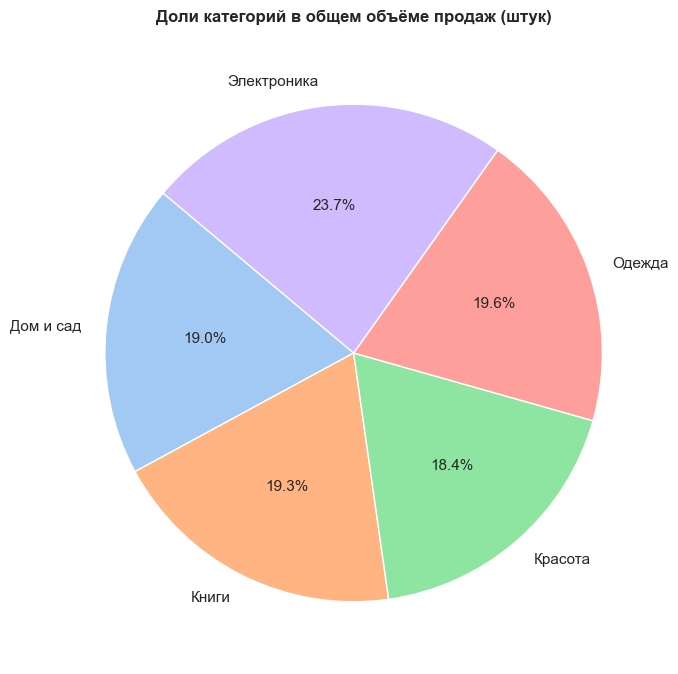

In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Включаем отображение графиков прямо в интерфейсе ноутбука
%matplotlib inline

# Настраиваем красивый и современный стиль визуализации
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})

print("Устанавливаем соединение с PostgreSQL...")
try:
    conn = psycopg2.connect(
        host="127.0.0.1", 
        port="5439", 
        user="postgres", 
        password="postgres", 
        database="shop_db"
    )
    print("Соединение успешно установлено!")
except Exception as e:
    print("Ошибка подключения! Убедись, что контейнер с базой запущен.")
    raise e

# 1. Загружаем данные из витрин
df_products = pd.read_sql("SELECT * FROM mart.product_sales;", conn)
df_customers = pd.read_sql("SELECT * FROM mart.customer_value;", conn)

# 2. Дозагружаем сырые данные для графиков динамики и оценок
df_orders_raw = pd.read_sql("SELECT order_id, order_date, total_amount FROM public.orders WHERE status = 'Completed';", conn)
df_reviews_raw = pd.read_sql("SELECT rating FROM public.reviews;", conn)
df_products_raw = pd.read_sql("SELECT product_id, category FROM public.products;", conn)
df_items_raw = pd.read_sql("SELECT order_id, product_id, quantity, price_at_order FROM public.order_items;", conn)

# Закрываем соединение, данные в памяти Python
conn.close()

# ------------------------------------------------------------------
# ГРАФИК 1: Топ товаров по выручке
# ------------------------------------------------------------------
plt.figure(figsize=(12, 5))
top_products = df_products.sort_values(by="total_revenue", ascending=False).head(10)

sns.barplot(
    data=top_products, 
    x="total_revenue", 
    y="name", 
    hue="category", 
    dodge=False
)
plt.title("Топ-10 товаров по объёму выручки", pad=15, weight='bold')
plt.xlabel("Выручка (в рублях)")
plt.ylabel("Наименование товара")
plt.legend(title="Категория", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# ГРАФИК 2: Динамика продаж по категориям (По месяцам)
# ------------------------------------------------------------------
plt.figure(figsize=(12, 6))

# Собираем данные: джойним даты заказов, позиции и категории продуктов
df_orders_raw['order_date'] = pd.to_datetime(df_orders_raw['order_date'])
df_orders_raw['month'] = df_orders_raw['order_date'].dt.to_period('M').dt.to_timestamp()

df_timeline = df_items_raw.merge(df_products_raw, on='product_id')
df_timeline = df_timeline.merge(df_orders_raw, on='order_id')
df_timeline['revenue'] = df_timeline['quantity'] * df_timeline['price_at_order']

# Группируем выручку по месяцам и категориям
df_dynamic = df_timeline.groupby(['month', 'category'])['revenue'].sum().reset_index()

sns.lineplot(
    data=df_dynamic, 
    x="month", 
    y="revenue", 
    hue="category", 
    marker="o", 
    linewidth=2.5
)
plt.title("Динамика выручки по категориям товаров (по месяцам)", pad=15, weight='bold')
plt.xlabel("Дата (Месяц)")
plt.ylabel("Выручка (руб.)")
plt.xticks(rotation=45)
plt.legend(title="Категория", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# ГРАФИК 3: Распределение оценок товаров
# ------------------------------------------------------------------
plt.figure(figsize=(8, 4))
rating_counts = df_reviews_raw['rating'].value_counts().sort_index()

sns.barplot(
    x=rating_counts.index, 
    y=rating_counts.values, 
    palette="vlag"
)
plt.title("Распределение оценок товаров от покупателей", pad=15, weight='bold')
plt.xlabel("Выставленная оценка (Звёзд)")
plt.ylabel("Количество отзывов")
for i, val in enumerate(rating_counts.values):
    plt.text(i, val + 10, str(val), ha='center', weight='bold')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# ГРАФИК 4: Сегментация покупателей по сумме покупок (Monetary - RFM)
# ------------------------------------------------------------------
plt.figure(figsize=(10, 5))

def get_segment(spent):
    if spent >= 70000: return 'Постоянные VIP (Высокий чек)'
    elif spent >= 30000: return 'Middle-класс (Средний чек)'
    else: return 'Эконом / Новички (Низкий чек)'

df_customers['segment'] = df_customers['total_spent'].apply(get_segment)
segment_counts = df_customers['segment'].value_counts().reindex([
    'Постоянные VIP (Высокий чек)', 'Middle-класс (Средний чек)', 'Эконом / Новички (Низкий чек)'
])

sns.barplot(
    x=segment_counts.values, 
    y=segment_counts.index, 
    palette="viridis"
)
plt.title("Сегментация покупателей по сумме покупок (Компонент Monetary в RFM)", pad=15, weight='bold')
plt.xlabel("Количество покупателей в сегменте")
plt.ylabel("Категория клиента")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# БОНУС-ГРАФИК 5: Соотношение категорий товаров по количеству продаж
# ------------------------------------------------------------------
plt.figure(figsize=(7, 7))
category_sales = df_products.groupby("category")["total_quantity_sold"].sum()

plt.pie(
    category_sales, 
    labels=category_sales.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette("pastel")
)
plt.title("Доли категорий в общем объёме продаж (штук)", pad=15, weight='bold')
plt.tight_layout()
plt.show()